In [1]:
%pip uninstall -y cyclical-fractional-test
%pip install --no-cache-dir --force-reinstall -e .

Found existing installation: cyclical-fractional-test 0.1.0
Uninstalling cyclical-fractional-test-0.1.0:
  Successfully uninstalled cyclical-fractional-test-0.1.0
Note: you may need to restart the kernel to use updated packages.
Obtaining file:///Users/asierlanda/OneDrive%20-%20KPMG/Desktop/master/TFM/log_memory_cycles
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.2/5.2 MB 15.9 MB/s  0:00:00 eta 0:00:01
  Building editable for cyclical-fractional-test (pyproject.toml) ... done
  Created wheel for cyclical-fractional-test: filename=cyclical_fractional_test-0.1.0-0.editable-py3-none-any.whl size=4902 sha256=89a9377aa1bcb1d4d08627e0dcdd25404c513eb5b809afdd5e0e0aab7ed9409b
  Stored in directory: /private/var/folders/04/st_535kd1r53zz13xp15rv9w0000gn/T/pip-ephem-wheel-cache-a644mvht/whe

In [2]:
import numpy as np
from cyclical_fractional_test import CyclicalTestConfig, run_cyclical_fractional_test, compute_periodogram
from datetime import timezone
import time

import pandas as pd
from pathlib import Path
import requests
import matplotlib.pyplot as plt
from urllib.parse import quote

In [3]:
import logging

logging.basicConfig(
    level=logging.INFO,
    format="%(levelname)s:%(name)s:%(message)s",
    force=True,  # importante en notebooks
)

In [4]:
# Variables de entrada
A = "2021-01-01 00:00:00"
B = "2025-01-01 00:00:00"
INTERVAL = "1d"

# Bitcoin en Binance.
SYMBOL = "BTCUSDT"
MARKET = "spot"  # "spot" o "um_futures"

# S&P 500 en Yahoo Finance.
SP500_SYMBOL = "^GSPC"

LIMIT = 1000
REQUEST_PAUSE_SECONDS = 0.2

ENDPOINTS = {
    "spot": "https://api.binance.com/api/v3/klines",
    "um_futures": "https://fapi.binance.com/fapi/v1/klines",
}

DATA_DIR = Path('data')
DATA_DIR.mkdir(exist_ok= True)

In [5]:
def to_milliseconds(value: str) -> int:
    timestamp = pd.Timestamp(value)
    if timestamp.tzinfo is None:
        timestamp = timestamp.tz_localize(timezone.utc)
    else:
        timestamp = timestamp.tz_convert(timezone.utc)
    return int(timestamp.timestamp() * 1000)


def to_seconds(value: str) -> int:
    return to_milliseconds(value) // 1000


def interval_to_milliseconds(interval: str) -> int:
    units = {
        "m": 60_000,
        "h": 60 * 60_000,
        "d": 24 * 60 * 60_000,
        "w": 7 * 24 * 60 * 60_000,
    }
    unit = interval[-1]
    if unit not in units:
        raise ValueError(f"Intervalo no soportado por esta funcion: {interval!r}")
    return int(interval[:-1]) * units[unit]


def fetch_binance_klines(symbol: str, start: str, end: str, interval: str = "1h", market: str = "spot") -> pd.DataFrame:
    if market not in ENDPOINTS:
        raise ValueError(f"MARKET debe ser uno de {list(ENDPOINTS)}")

    endpoint = ENDPOINTS[market]
    start_ms = to_milliseconds(start)
    end_ms = to_milliseconds(end)
    step_ms = interval_to_milliseconds(interval)
    rows = []

    while start_ms < end_ms:
        params = {
            "symbol": symbol.upper(),
            "interval": interval,
            "startTime": start_ms,
            "endTime": end_ms,
            "limit": LIMIT,
        }
        response = requests.get(endpoint, params=params, timeout=30)
        response.raise_for_status()
        batch = response.json()

        if isinstance(batch, dict):
            raise RuntimeError(f"Error de Binance: {batch}")
        if not batch:
            break

        rows.extend(batch)
        last_open_time = batch[-1][0]
        next_start_ms = last_open_time + step_ms
        if next_start_ms <= start_ms:
            break
        start_ms = next_start_ms

        if len(batch) == LIMIT:
            time.sleep(REQUEST_PAUSE_SECONDS)

    columns = [
        "open_time",
        "open",
        "high",
        "low",
        "close",
        "volume",
        "close_time",
        "quote_asset_volume",
        "number_of_trades",
        "taker_buy_base_asset_volume",
        "taker_buy_quote_asset_volume",
        "ignore",
    ]
    df = pd.DataFrame(rows, columns=columns)
    if df.empty:
        return df

    numeric_columns = [
        "open",
        "high",
        "low",
        "close",
        "volume",
        "quote_asset_volume",
        "taker_buy_base_asset_volume",
        "taker_buy_quote_asset_volume",
    ]
    df["open_time"] = pd.to_datetime(df["open_time"], unit="ms", utc=True)
    df["close_time"] = pd.to_datetime(df["close_time"], unit="ms", utc=True)
    df[numeric_columns] = df[numeric_columns].apply(pd.to_numeric, errors="coerce")
    df["number_of_trades"] = pd.to_numeric(df["number_of_trades"], errors="coerce").astype("Int64")

    end_timestamp = pd.Timestamp(end)
    if end_timestamp.tzinfo is None:
        end_timestamp = end_timestamp.tz_localize(timezone.utc)
    else:
        end_timestamp = end_timestamp.tz_convert(timezone.utc)

    return df.loc[df["open_time"] < end_timestamp].reset_index(drop=True)


def fetch_yahoo_prices(symbol: str, start: str, end: str, interval: str = "1d") -> pd.DataFrame:
    endpoint = f"https://query1.finance.yahoo.com/v8/finance/chart/{quote(symbol, safe='')}"
    params = {
        "period1": to_seconds(start),
        "period2": to_seconds(end),
        "interval": interval,
        "events": "history",
        "includeAdjustedClose": "true",
    }
    headers = {"User-Agent": "Mozilla/5.0"}
    response = requests.get(endpoint, params=params, headers=headers, timeout=30)
    response.raise_for_status()
    payload = response.json()

    chart = payload.get("chart", {})
    error = chart.get("error")
    if error:
        raise RuntimeError(f"Error de Yahoo Finance: {error}")

    results = chart.get("result") or []
    if not results:
        return pd.DataFrame(columns=["open_time", "open", "high", "low", "close", "volume"])

    result = results[0]
    timestamps = result.get("timestamp") or []
    if not timestamps:
        return pd.DataFrame(columns=["open_time", "open", "high", "low", "close", "volume"])

    quote_data = (result.get("indicators", {}).get("quote") or [{}])[0]
    df = pd.DataFrame({
        "open_time": pd.to_datetime(timestamps, unit="s", utc=True),
        "open": quote_data.get("open"),
        "high": quote_data.get("high"),
        "low": quote_data.get("low"),
        "close": quote_data.get("close"),
        "volume": quote_data.get("volume"),
    })
    numeric_columns = ["open", "high", "low", "close", "volume"]
    df[numeric_columns] = df[numeric_columns].apply(pd.to_numeric, errors="coerce")

    end_timestamp = pd.Timestamp(end)
    if end_timestamp.tzinfo is None:
        end_timestamp = end_timestamp.tz_localize(timezone.utc)
    else:
        end_timestamp = end_timestamp.tz_convert(timezone.utc)

    return df.dropna(subset=["open"]).loc[df["open_time"] < end_timestamp].reset_index(drop=True)


bitcoin_prices = fetch_binance_klines(SYMBOL, A, B, INTERVAL, MARKET)
bitcoin_prices[['open_time', 'open']].to_csv(DATA_DIR / 'btc_prices_1d.csv', index = False)

sp500_prices = fetch_yahoo_prices(SP500_SYMBOL, A, B, INTERVAL)
sp500_prices[['open_time', 'open']].to_csv(DATA_DIR / 'sp500_prices_1d.csv', index = False)

In [7]:
import sys
import logging
import importlib
import pandas as pd
from pathlib import Path
import numpy as np

# 1. Asegura que Python mira al repo local
repo_root = Path("/Users/asierlanda/Desktop/master/TFM/log_memory_cycles")
src_path = repo_root / "src"

if str(src_path) in sys.path:
    sys.path.remove(str(src_path))
sys.path.insert(0, str(src_path))

# 2. Fuerza recarga del módulo local
import cyclical_fractional_test.api as api
api = importlib.reload(api)

print(api.__file__)  # debe apuntar a src/cyclical_fractional_test/api.py

# 3. Configura logger DIRECTAMENTE sobre ese módulo
handler = logging.StreamHandler(sys.stdout)
handler.setLevel(logging.INFO)
handler.setFormatter(logging.Formatter("%(levelname)s:%(name)s:%(message)s"))

api.logger.handlers.clear()
api.logger.addHandler(handler)
api.logger.setLevel(logging.WARNING)
# api.logger.setLevel(logging.INFO)
api.logger.propagate = False

test_config = api.CyclicalTestConfig(
    n_deterministic_cycles= 3,
    include_intercept= False,
    d_grid= np.linspace(0.0, 1.0, 101),
    r_window= 10,
    top_k= 5,
    statistic_mode= 'test',
    stochastic_cycle_mode= 'single',
    exclude_zero_frequency= True,
    error_model= 'ar2',
)

DATA_DIR = Path('data')
DATA_DIR.mkdir(exist_ok= True)

df = pd.read_csv(DATA_DIR / 'MONTHLY.csv', sep = ';')
y = df.iloc[:,3:7].astype(float).dropna()
y.head()

/Users/asierlanda/OneDrive - KPMG/Desktop/master/TFM/log_memory_cycles/src/cyclical_fractional_test/api.py


,sunspot_mean,sunspot_std,n_observations,definitive
0,58.1,9.7,8.0,1.0
1,37.4,7.8,14.0,1.0
2,42.4,8.3,14.0,1.0
3,57.5,9.6,21.0,1.0
4,88.5,11.9,25.0,1.0


In [6]:
for col in y.columns:
    print(f"\n{'='*50}")
    print(f"Column: {col}")
    print('='*50)

    y_col = y[col].values

    result_col = api.run_cyclical_fractional_test(y_col, config=test_config)
    best_col = result_col.best_result
    cycle_col = best_col.cycles[0]

    print('best R:', cycle_col.R, '  best D:', cycle_col.D)
    print('betas:', best_col.betas)
    print('test_value:', best_col.test_value)
    print('test_star_value:', best_col.test_star_value)
    print('best xa:', best_col.xa, '  best xaa:', best_col.xaa)
    print('variance_time:', best_col.variance_time, '  variance_frequency:', best_col.variance_frequency)



Column: sunspot_mean
best R: 20   best D: 0.5
betas: [ 1.2231825   3.31744813 12.37726809]
test_value: -0.27088147135969515
test_star_value: -0.27088866325368327
best xa: -6.021899367446125   best xaa: 2.214832746547249
variance_time: 746.8849877653773   variance_frequency: 746.865158520444

Column: sunspot_std


KeyboardInterrupt: 

In [8]:
api.logger.setLevel(logging.WARNING)
# api.logger.setLevel(logging.INFO)
y_fist_differences = np.diff(y.to_numpy(), axis=0)

result = api.run_cyclical_fractional_test(y, config= test_config)

best = result.best_result
cycle = best.cycles[0]

print('best R:',cycle.R,'best D:', cycle.D)
print('betas:', best.betas)

print('test_value:', best.test_value)
print(best.test_star_value)
print('best xa:', best.xa,'best xaa:', best.xaa)
print(best.variance_time, best.variance_frequency)


InvalidSeriesError: Series y must be 1-dimensional, got shape (2500, 4).

lambda: 0 I: 2790636.1835848424 len: 2500


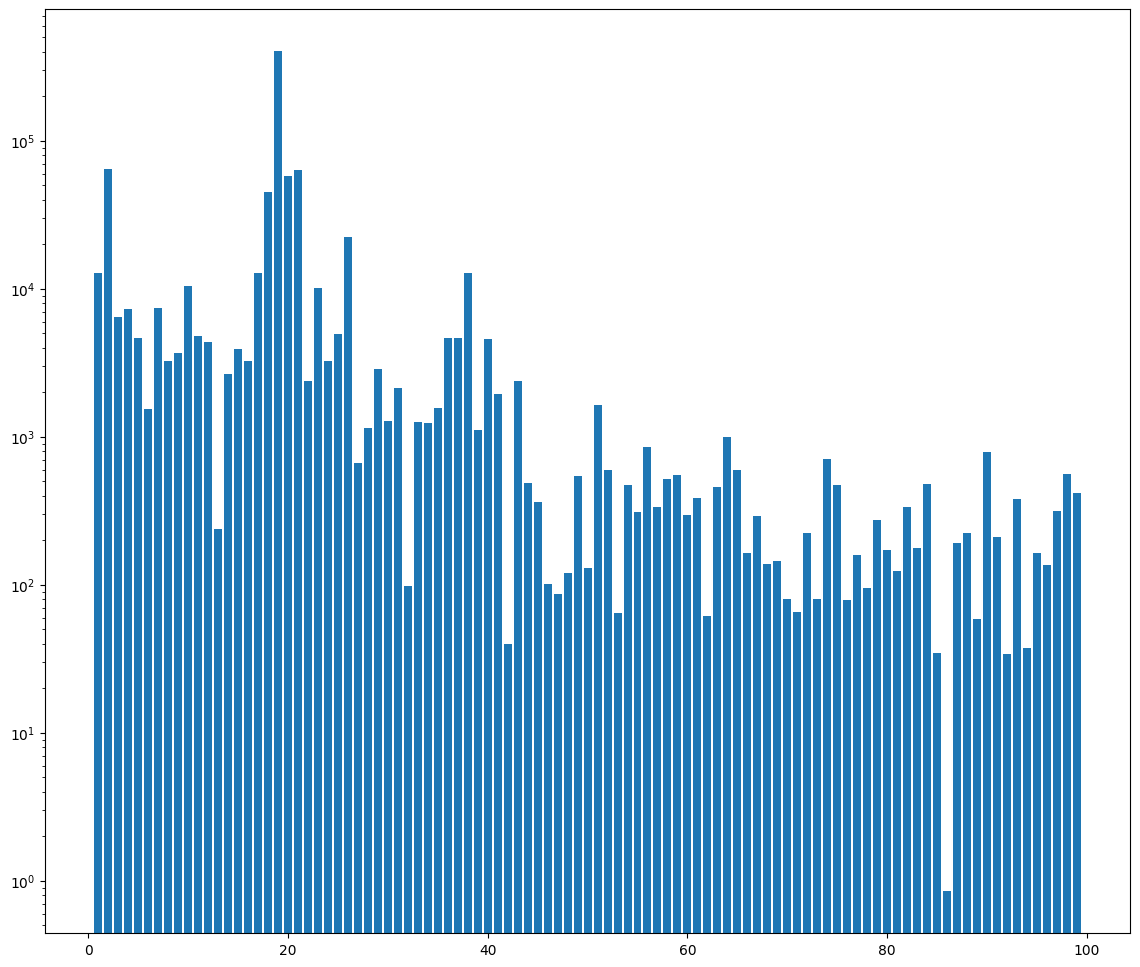

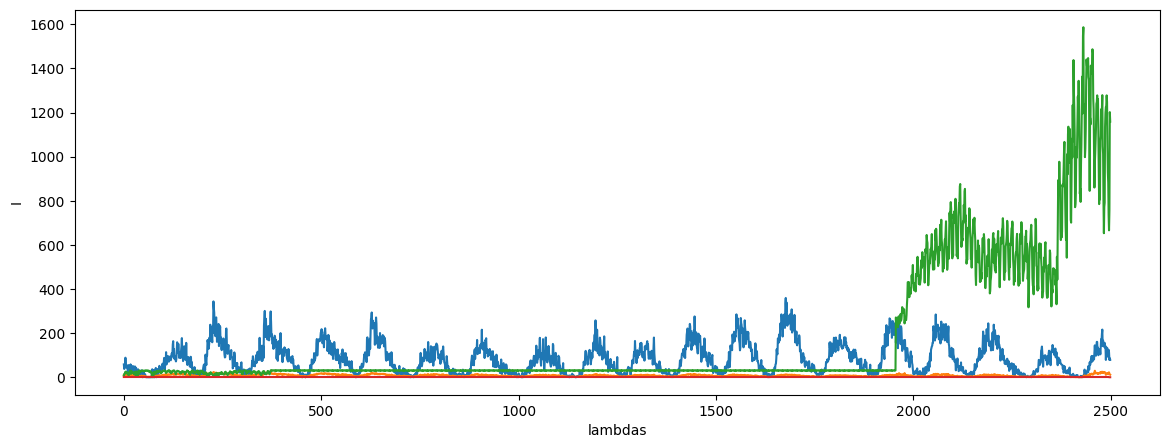

In [13]:
import matplotlib.pyplot as plt

lambdas, I = api.compute_periodogram(y.iloc[:, 0])

jey = range(len(lambdas))

higest = 0
for i in range(len(I)):
    if I[i] > higest:
        higest = I[i]
        j = i
print('lambda:', jey[j], 'I:', I[j], 'len:', len(I))


min_range = 1
max_range = 100

# print(lambdas, I)
plt.figure(figsize= [14, 12])
plt.bar(jey[min_range:max_range], I[min_range:max_range])
plt.yscale('log')
# Çprint(I[min_range: max_range].max(), I[min_range: max_range].argmax() + min_range)
plt.figure(figsize=[14,5])
plt.plot(y)
# plt.hist(I, bins = 50)
plt.xlabel('lambdas')
plt.ylabel('I')
plt.show()